In [ ]:
print('test')

test


In [ ]:
# 1. 문제 정의 : 200개 시장에 대한 TV·라디오·신문 광고비와 판매량에 대한 분석

In [30]:
# 2. 데이터 수집
import pandas as pd

df = pd.read_csv('../dataset/Adversiting.csv', encoding='utf-8')
df.head()

,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [31]:
# 데이터 리셋으로 사용, 실수 방지용
df2 = df.copy()

In [32]:
# 데이터 전처리 및 EDA
df2 = df2.drop(columns=['ID'])

In [17]:
df2.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [14]:
df2.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
df2.info()

# 모든 컬럼 200 non-null : 결측치 없음 확인
# 문자열 데이터 없음

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
df2.duplicated().sum()

# 중복 데이터 없음

np.int64(0)

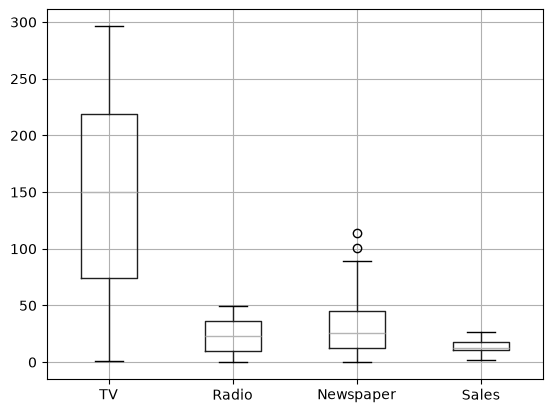

In [19]:
import matplotlib.pyplot as plt

df2.boxplot()
plt.show()

In [33]:
df2.sort_values(by='Newspaper', ascending=False).head(10)

# 뉴스 광고에 이상치 2개 확인하고 정렬해보았으나 
# 현실적으로 있을 수 없는 수치는 아니라고 생각하여 그대로 진행

,TV,Radio,Newspaper,Sales
16,67.8,36.6,114.0,12.5
101,296.4,36.3,100.9,23.8
75,16.9,43.7,89.4,8.7
165,234.5,3.4,84.8,11.9
118,125.7,36.9,79.2,15.9
141,193.7,35.4,75.6,19.2
5,8.7,48.9,75.0,7.2
124,229.5,32.3,74.2,19.7
88,88.3,25.5,73.4,12.9
93,250.9,36.5,72.3,22.2


In [ ]:
df2.corr()

# 다중공선성 확인 : 변수 간 상관 관계 전부 0.6미만, 강한 상관관계 없음 확인

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [36]:
# 독립변수와 종속변수 분리
X = df2[['TV', 'Radio', 'Newspaper']]
y = df2['Sales']


In [37]:
# 4. 데이터 분할
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size= 0.2,
    random_state=42
)

In [42]:
# 5. 모델 학습
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# 6. 학습
model.fit(X_train, y_train);

In [ ]:
# 7. 학습된 결과 예측

y_pred = model.predict(X_test)
print(X_test)
print(y_pred)

        TV  Radio  Newspaper
95   163.3   31.6       52.9
15   195.4   47.7       52.9
30   292.9   28.3       43.2
158   11.7   36.9       45.2
128  220.3   49.0        3.2
115   75.1   35.0       52.7
69   216.8   43.9       27.2
170   50.0   11.6       18.4
174  222.4    3.4       13.1
45   175.1   22.5       31.5
66    31.5   24.6        2.2
182   56.2    5.7       29.7
165  234.5    3.4       84.8
78     5.4   29.9        9.4
186  139.5    2.1       26.6
177  170.2    7.8       35.2
56     7.3   28.1       41.4
152  197.6   23.3       14.2
82    75.3   20.3       32.5
68   237.4   27.5       11.0
124  229.5   32.3       74.2
16    67.8   36.6      114.0
148   38.0   40.3       11.9
93   250.9   36.5       72.3
65    69.0    9.3        0.9
60    53.5    2.0       21.4
84   213.5   43.0       33.8
67   139.3   14.5       10.2
125   87.2   11.8       25.9
132    8.4   27.2        2.1
9    199.8    2.6       21.2
18    69.2   20.5       18.3
55   198.9   49.4       60.0
75    16.9   4

In [ ]:
# 8. 평가 및 튜닝

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

# 평가지수 높음

0.899438024100912


In [ ]:
# 9. 새로운 데이터 예측

new_data = pd.DataFrame({
    'TV': [200],
    'Radio': [50],
    'Newspaper': [30]
})

new_pred = model.predict(new_data)
print(new_pred)

[21.46755697]


In [ ]:
# 10 결과 출력

print("R-squared 값:", r2)
print("예측 판매량:", new_pred)

R-squared 값: 0.899438024100912
예측 판매량: [21.46755697]


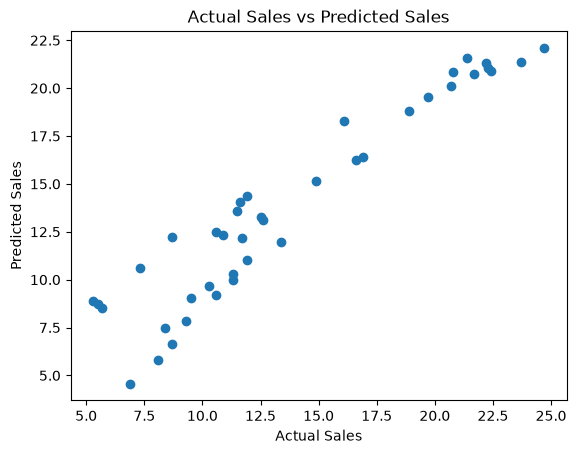

In [52]:
# 11. 시각화
# 실제 판매량 vs 예측 판매량 산점도
plt.scatter(y_test, y_pred)

plt.title('Actual Sales vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.show()

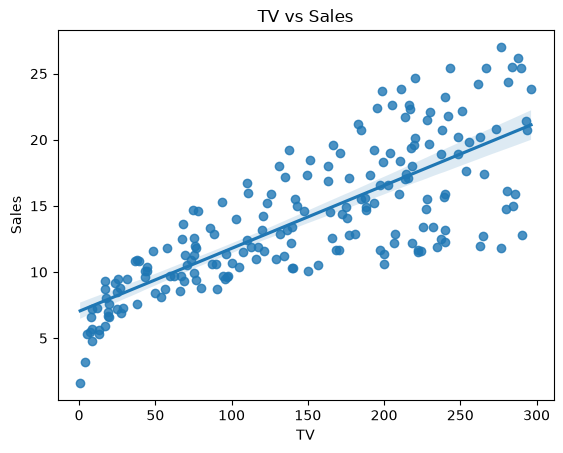

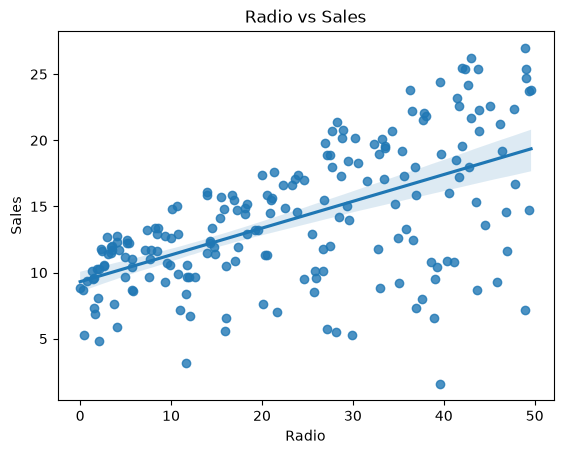

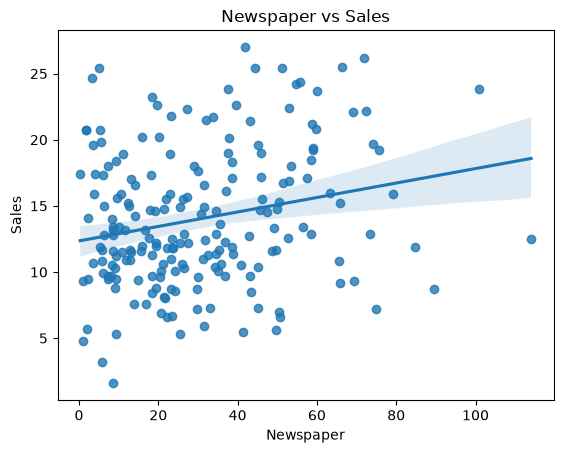

In [ ]:
# 각 독립변수와 판매량과의 관계 시각화
import seaborn as sns

features = ['TV', 'Radio', 'Newspaper']

for feature in features:
    sns.regplot(x=feature, y='Sales', data=df2)
    plt.title(f"{feature} vs Sales")
    plt.xlabel(feature)
    plt.ylabel('Sales')
    plt.show()

In [ ]:
# sns.regplot() : 
# 실제 데이터 = 점
# 진한 선 = 추정된 회귀선
# 연한 하늘색 영역 : 95% 신뢰구간 표시

# 오른쪽으로 갈수록 하늘색 영역이 넓어지는 것은 
# 보통 그 구간에 데이터가 상대적으로 적거나 변동성이 커서 회귀선 추정의 불확실성이 커진 것

# 없애고 싶으면: sns.regplot(x=feature, y='Sales', data=df2, ci=None)

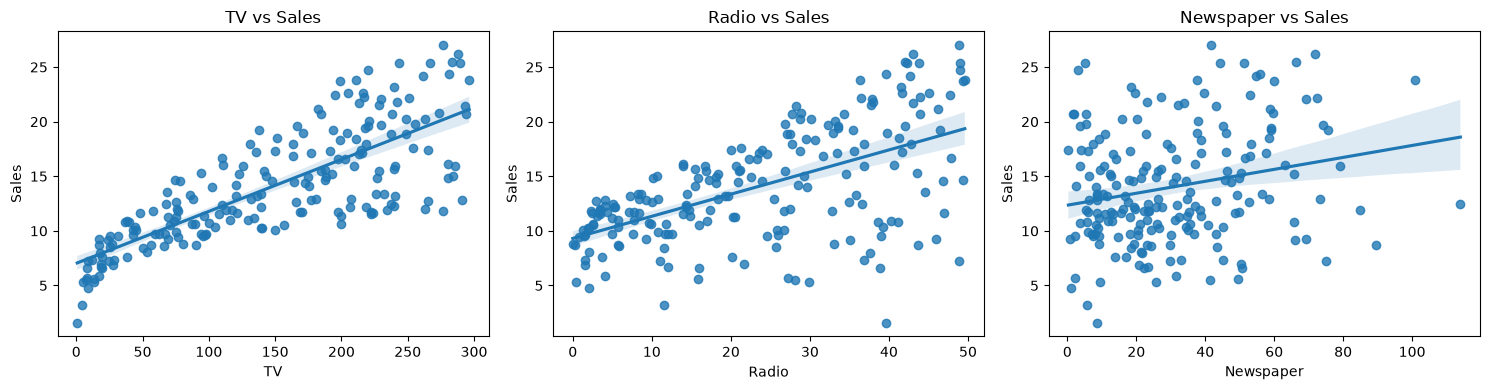

In [ ]:
## (추가) 한 화면에 3개를 나란히 보여주는 방식

features = ['TV', 'Radio', 'Newspaper']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(features):
    sns.regplot(
        x=feature,
        y='Sales',
        data=df2,
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} vs Sales')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Sales')

plt.tight_layout()
plt.show()

In [ ]:
# plt.subplots : “하나의 큰 그림 안에 여러 개의 그래프 칸을 만드는 기능
# fig : 전체 그림판
# axes : 도화지 안에 영역

# enumerate(features) : 순서 번호와 값 둘 다 가져오는 기능
# subplots로 1행 3열로 공간을 나누고 그 공간 하나를 axes[인덱스]로 표현